# Lab 12: Statistical Testing with Random Graph Null Models

In earlier labs, we compared observed networks to random graphs informally.
In this lab, that comparison becomes explicit statistical testing.

We will:
- choose a graph statistic,
- state a null hypothesis $\mathcal{H}_0$,
- state an alternative hypothesis $\mathcal{H}_1$,
- generate many graphs from a null model,
- compute the statistic under the null model,
- compare the observed graph to that null distribution,
- estimate an empirical $p$-value.

Our goal is not only to say that an observed graph “looks unusual,” but to ask whether it appears unusual relative to a clearly stated null model.

In [1]:
from lab12_helpers import *
import pandas as pd
import networkx as nx

### Part 1: The observed graph and the null model

We begin with an observed graph: Zachary's Karate Club graph.

Our null model will be $G(n,m)$: a random graph with the same number of vertices and edges as the observed graph.

This means the null model preserves graph size, but places the edges at random.

In [2]:
K = karate_graph()
observed_metrics = graph_metrics(K)
observed_metrics

{'nodes': 34,
 'edges': 78,
 'connected_components': 1,
 'largest_component_size': 34,
 'average_degree': 4.588235294117647,
 'average_path_length': 2.408199643493761,
 'average_clustering': 0.5706384782076823,
 'transitivity': 0.2556818181818182,
 'density': 0.13903743315508021}

For the clustering test, we will use:


$\mathcal{H}_0$: The observed graph is consistent with a $G(n,m)$ random graph model.


$\mathcal{H}_1$: The observed graph has larger average clustering than expected under $G(n,m)$.

This is a one-sided test because we are specifically asking whether the observed clustering is unusually high.

### Part 2: Simulating the null distribution

To test the hypothesis, we generate many random graphs from the null model and compute the same statistic on each one. Here, we will simulate 500 times. This is likely overkill for such a simple example, but imagine using this workflow on a large, complex graph system. Minor deviations in the structure across random trials can give untrustworthy statistics, so we hope to "smooth those out" by oversampling.

This gives a null distribution for average clustering.

In [3]:
null_df = simulate_matching_observed(K, trials=500, seed=12)
null_df.head()

,nodes,edges,connected_components,largest_component_size,average_degree,average_path_length,average_clustering,transitivity,density
0,34,78,1,34,4.588235,2.415330,0.126751,0.139942,0.139037
1,34,78,1,34,4.588235,2.449198,0.171452,0.155488,0.139037
2,34,78,1,34,4.588235,2.367201,0.153898,0.123894,0.139037
3,34,78,1,34,4.588235,2.433155,0.214496,0.139942,0.139037
4,34,78,1,34,4.588235,2.393939,0.150000,0.172911,0.139037


In [4]:
observed_clustering = observed_metrics["average_clustering"]
observed_path_length = observed_metrics["average_path_length"]

print(f"Observed clustering: {observed_clustering}, \nObserved path length: {observed_path_length}")
print("\n ****** Null statistics ******")
null_df["average_clustering"].describe()

Observed clustering: 0.5706384782076823, 
Observed path length: 2.408199643493761

 ****** Null statistics ******


count    500.000000
mean       0.134571
std        0.034703
min        0.046989
25%        0.110218
50%        0.133007
75%        0.157655
max        0.255065
Name: average_clustering, dtype: float64

### Part 3: Visualizing the null distribution

Now compare the observed clustering coefficient to the distribution of clustering coefficients under the null model.

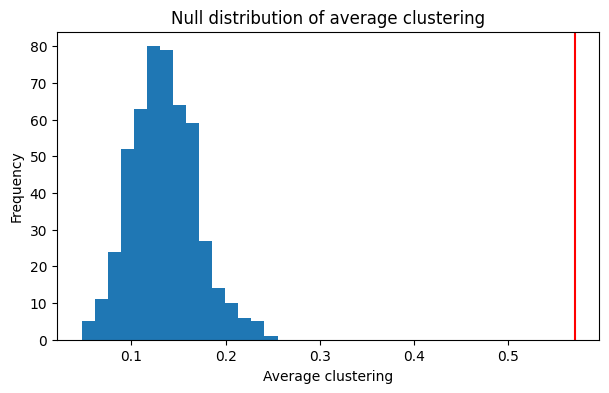

In [5]:
plot_metric_histogram(
    null_df["average_clustering"],
    observed_value=observed_clustering,
    xlabel="Average clustering",
    title="Null distribution of average clustering"
)

Very clearly the observed value is way outside the null distribution, but we will continue setting up the workflow for application to harder cases later.

### Part 4: Estimating an empirical $p$-value

For this one-sided test, the empirical $p$-value is the proportion of null-model graphs whose clustering coefficient is at least as large as the observed one.

A very small $p$-value means that the observed clustering would be rare under the null model.

In [6]:
empirical_p_value_upper(null_df["average_clustering"], observed_clustering)

0.001996007984031936

Interpretation questions:

- If the empirical $p$-value is very small, what does that say about $\mathcal{H}_0$?
- Does it prove that the null model is false?
- Or does it say that the observed graph would be unusual if $\mathcal{H}_0$ were true?

### Part 5: A second test using average path length

Now repeat the process using average path length.

This time, we may not know in advance whether the observed graph should be larger or smaller than the null-model average path length, so a two-sided interpretation is more natural.

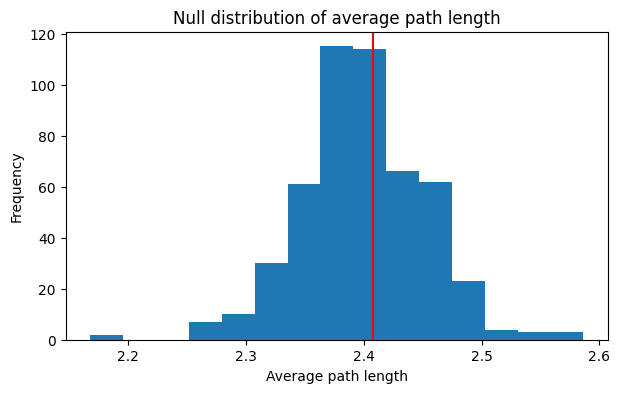

In [7]:
plot_metric_histogram(
    null_df["average_path_length"],
    observed_value=observed_path_length,
    xlabel="Average path length",
    title="Null distribution of average path length"
)

In [8]:
empirical_p_value_two_sided(null_df["average_path_length"], observed_path_length)

0.8483033932135728

For this test, use:

$\mathcal{H}_0$: The observed graph is consistent with the $G(n,m)$ null model in average path length.

$\mathcal{H}_1$: The observed graph has an average path length that is unusually different from the null model.

Questions:
- Does the observed path length look unusual?
- Is clustering or path length the stronger signal against the null model?
- Why might one statistic show stronger evidence than another?

### Part 6: The null model matters

A hypothesis test depends on the null model.

Now compare the same observed graph to a different null model, $G(n,p)$, where $p$ is chosen so that the expected number of edges matches the observed graph.

In [32]:
n = K.number_of_nodes()
m = K.number_of_edges()
# let's define an "inflation factor" that forces more connections
# play around with some larger and smaller factors to see the influence on the p-value
inf_factor = 8.0
p = (inf_factor * m) / (n * (n - 1))
p

0.5561497326203209

In [33]:
gnp_df = simulate_gnp_metrics(n, p, trials=500, seed=21)
gnp_df.head()

,nodes,edges,connected_components,largest_component_size,average_degree,average_path_length,average_clustering,transitivity,density
0,34,317,1,34,18.647059,1.434938,0.565628,0.563550,0.565062
1,34,296,1,34,17.411765,1.472371,0.532074,0.532171,0.527629
2,34,291,1,34,17.117647,1.481283,0.523140,0.526131,0.518717
3,34,298,1,34,17.529412,1.468806,0.528916,0.530665,0.531194
4,34,316,1,34,18.588235,1.436720,0.553233,0.551053,0.563280


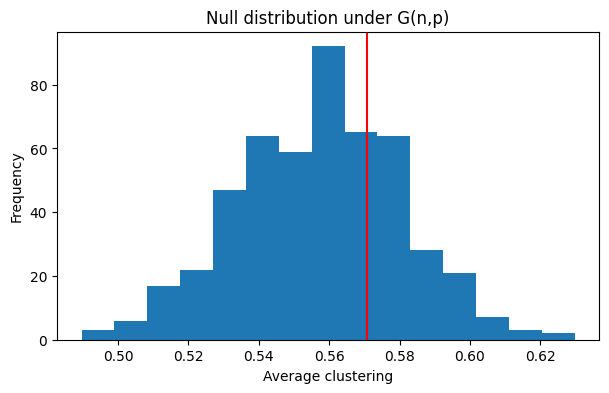

In [34]:
plot_metric_histogram(
    gnp_df["average_clustering"],
    observed_value=observed_clustering,
    xlabel="Average clustering",
    title="Null distribution under G(n,p)"
)

In [35]:
empirical_p_value_upper(gnp_df["average_clustering"], observed_clustering)

0.281437125748503

Questions:
- Does the $p$-value change when the null model changes?
- Why is hypothesis testing always tied to modeling assumptions?
- What does this tell you about statistical evidence in network science?